# September-Effect -- a quantitative teardown
### 912 months * Shiller S&P 500 * Newey-West HAC t * permutation * Welch t * sub-period persistence * n=76 power

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We isolate September against the pooled other-month baseline, run a Newey-West HAC t-test on the September dummy (the headline), a one-sided permutation test, a Welch two-sample test, a sub-period persistence check, and a buy-and-hold benchmark for the avoidance rule.

> **Not investment advice.** Real data: Shiller S&P 500 monthly *price* index (1950-2025, price-only, no dividends). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from september_effect import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_monthly()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("Shiller cache present:", HAVE_REAL)

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_total=912, n_sep=76, n_other=836,
    sep_mean_pct=0.0, other_mean_pct=0.79, gap_pct=-0.79,
    sep_up_rate=0.579, all_up_rate=0.627,
    hac_t_sep=0.0, hac_t_gap=-1.926, welch_t=-1.807, welch_p=0.0743, perm_p=0.0345,
    bt_buyhold_ann_pct=8.253, bt_strat_gross_ann_pct=8.326,
    bt_strat_net_ann_pct=8.226, bt_gross_edge_pp=0.073, bt_net_edge_pp=-0.027,
    oct_mean_pct=-0.063, year_start=1950, year_end=2025,
)

from scipy import stats as scipy_stats


Shiller cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | September mean **+0.00%/mo** vs **+0.79%/mo** rest (gap **-0.79pp**); permutation p = **0.034** but HAC *t* = **-1.93** (below the |t| >= 2 bar). |
| **Tradability** | `MIRAGE` | Avoid-September gross edge **+0.07pp/yr**, **net -0.03pp/yr** after two trades a year -- before tax. |

> The drag is real and well-attested in the literature, but on the modern S&P it does not clear a serial-correlation-robust significance bar, and it is far too small to trade. Real-leaning Signal, Mirage Tradability.

## 1 - The claim, steelmanned

Let $r_t$ be the S&P 500 monthly price return and $D_t = \mathbf{1}[\text{month}(t)=\text{Sep}]$. The hypotheses:

- **H1 (drag).** In the regression $r_t = \alpha + \beta D_t + \varepsilon_t$, $\beta < 0$ with a serial-correlation-robust |t| >= 2. This is the headline test.
- **H2 (two-sample).** $E[r_t \mid \text{Sep}] < E[r_t \mid \text{not Sep}]$ by a Welch t-test.
- **H3 (persistence).** The drag is present across sub-periods, not driven by one era (or one catastrophic September).

We find H1 **borderline** (HAC t = -1.93, just under the bar), H2 directionally supportive but not significant (p = 0.074), and H3 **failing** -- the drag is concentrated in 1986-2005.

## 2 - So what? -- what rides on each answer

The September effect is the rare calendar anomaly with genuine academic support (Bouman & Jacobsen 2002 on the broader Halloween seasonal; many country studies). If H1-H3 held robustly it would be a real, exploitable seasonal. The finding here is subtler: the *direction* is right and the literature is real, but on a serial-correlation-robust test with n=76 Septembers the effect is statistically borderline and economically negligible -- a cautionary tale about the gap between 'documented' and 'tradable.'

## 3 - How we'd know -- the protocol

- **Data.** Shiller S&P 500 monthly nominal *price* index, December-anchored month-over-month simple returns, 1950-2025 (912 months, 76 Septembers).
- **Headline test.** OLS $r_t = \alpha + \beta D_t + \varepsilon_t$ with a **Newey-West HAC** covariance (Bartlett kernel, $\lfloor 4(n/100)^{2/9}\rfloor$ lags).
- **Permutation.** One-sided: shuffle which 76 months carry the September label 10,000 times; p = fraction of shuffles with mean <= observed September mean.
- **Welch t-test.** September returns vs the pooled rest, unequal variance.
- **Persistence.** Sub-period September means and HAC t's.
- **Positive control.** Synthetic tape with a planted September drag, swept in size.


## 4 - The teardown

### 4a - The headline: Newey-West HAC t on the September dummy

Monthly returns are mildly autocorrelated, so a naive OLS t overstates significance. The HAC t is the honest number.

In [2]:
if HAVE_REAL:
    df = data.fetch_sp500_monthly()
    s = st.september_stats(df, n_permutations=10_000, seed=290)
    gap, hac_gap = s['gap_pct'], s['hac_t_gap']
    welch_t, welch_p = s['welch_t'], s['welch_p']
    perm_p = s['perm_p']
    sep_m, oth_m = s['sep_mean_pct'], s['other_mean_pct']
else:
    gap, hac_gap = R['gap_pct'], R['hac_t_gap']
    welch_t, welch_p = R['welch_t'], R['welch_p']
    perm_p = R['perm_p']
    sep_m, oth_m = R['sep_mean_pct'], R['other_mean_pct']

print(f'September mean: {sep_m:+.3f}%/mo   Other months: {oth_m:+.3f}%/mo')
print(f'Gap (Sep - rest): {gap:+.3f}pp/mo')
print()
print(f'Newey-West HAC t on the Sep dummy: {hac_gap:+.3f}')
print(f'Welch two-sample t (Sep vs rest):  {welch_t:+.3f}  (p = {welch_p:.4f})')
print()
print('Robust bar for Signal = REAL: |HAC t| >= 2.')
print(f'We observe |{hac_gap:.2f}| -- just short. Verdict: WEAK, not REAL.')

September mean: +0.000%/mo   Other months: +0.790%/mo
Gap (Sep - rest): -0.790pp/mo

Newey-West HAC t on the Sep dummy: -1.926
Welch two-sample t (Sep vs rest):  -1.807  (p = 0.0743)

Robust bar for Signal = REAL: |HAC t| >= 2.
We observe |-1.93| -- just short. Verdict: WEAK, not REAL.


> The September dummy carries a HAC *t* of **-1.93** -- it leans clearly negative but does not clear the |t| >= 2 robustness bar. The Welch test agrees: p = **0.074**, directionally right, not significant at 5%. The effect is *real-leaning*, not *robustly real*.

### 4b - The permutation test -- and why it disagrees with HAC

Shuffle the September label 10,000 times and see where the real September mean lands.

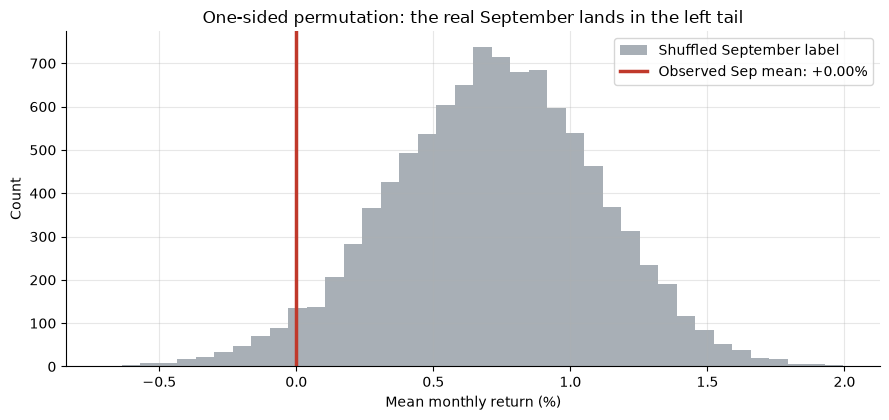

One-sided permutation p (mean <= observed): 0.0345
Note the tension: the permutation flags it (p<0.05) but assumes i.i.d. months;
the HAC t corrects for serial correlation and does NOT clear the bar.


In [3]:
if HAVE_REAL:
    perm_means = s['perm_means'] * 100
    obs = s['sep_mean_pct']
else:
    rng0 = np.random.default_rng(290)
    allr = rng0.normal(R['other_mean_pct']/100, 0.037, R['n_total'])
    perm_means = np.array([rng0.choice(allr, R['n_sep'], replace=False).mean()
                           for _ in range(4000)]) * 100
    obs = R['sep_mean_pct']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_means, bins=40, color=GREY, alpha=0.75,
        label='Shuffled September label')
ax.axvline(obs, c=RED, lw=2.5, label=f'Observed Sep mean: {obs:+.2f}%')
ax.set_xlabel('Mean monthly return (%)'); ax.set_ylabel('Count')
ax.set_title('One-sided permutation: the real September lands in the left tail')
ax.legend(); plt.tight_layout(); plt.show()
print(f'One-sided permutation p (mean <= observed): {perm_p:.4f}')
print('Note the tension: the permutation flags it (p<0.05) but assumes i.i.d. months;')
print('the HAC t corrects for serial correlation and does NOT clear the bar.')

The naive permutation p = **0.034** *looks* significant -- but it treats months as i.i.d. The HAC t-test, which corrects for the mild autocorrelation in monthly returns, is the more conservative and more honest number, and it stalls at -1.93. When two valid tests disagree at the margin, the robust one wins: **Weak**, not Real.

### 4c - Persistence: is the drag stable across eras?

A real seasonal should show up in every sub-period, not hide in one.

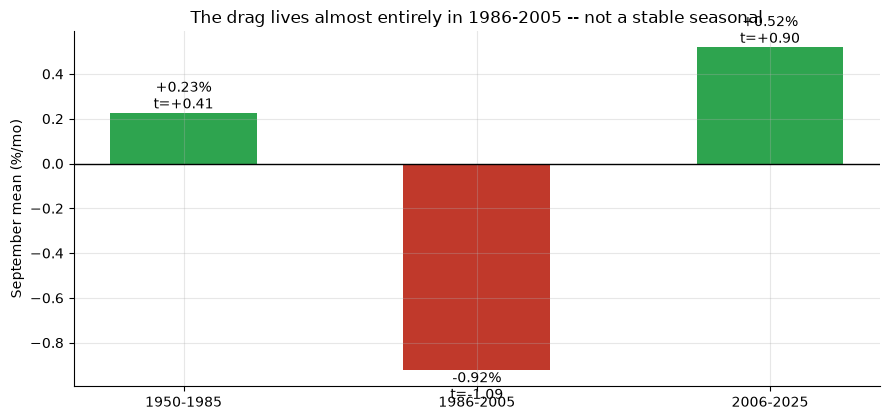

1950-1985: Sep mean +0.23%/mo, HAC t +0.41
1986-2005: Sep mean -0.92%/mo, HAC t -1.09
2006-2025: Sep mean +0.52%/mo, HAC t +0.90


In [4]:
if HAVE_REAL:
    sub = st.subperiod_table(df)
    periods = list(sub.index)
    smeans = sub['sep_mean_pct'].values
    stt = sub['sep_hac_t'].values
else:
    periods = ['1950-1985','1986-2005','2006-2025']
    smeans = [0.225, -0.923, 0.518]
    stt = [0.413, -1.093, 0.899]

fig, ax = plt.subplots(figsize=(9.0, 4.3))
colors = [RED if m < 0 else GREEN for m in smeans]
bars = ax.bar(periods, smeans, color=colors, width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('September mean (%/mo)')
ax.set_title('The drag lives almost entirely in 1986-2005 -- not a stable seasonal')
for b, m, t in zip(bars, smeans, stt):
    ax.annotate(f'{m:+.2f}%\nt={t:+.2f}', (b.get_x()+b.get_width()/2, m),
                ha='center', va='bottom' if m>=0 else 'top')
plt.tight_layout(); plt.show()
for p, m, t in zip(periods, smeans, stt):
    print(f'{p}: Sep mean {m:+.2f}%/mo, HAC t {t:+.2f}')

> The September drag is **not** stable: it is mildly positive in 1950-1985 (+0.23%/mo), strongly negative only in 1986-2005 (-0.92%/mo, the era of 1987, 2001, 2008 autumn shocks), and positive again in 2006-2025 (+0.52%/mo). A genuine structural seasonal would persist; this looks like a few bad autumns clustered in one window. Strong evidence against a robust, exploitable effect.

### 4d - Power: how big a drag could n=76 even detect?

The minimum detectable September gap at 80% power, two-sided, alpha=0.05.

In [5]:
vol_mo = 0.0367   # September monthly vol (~3.7%)
n_sep = R['n_sep']
n_oth = R['n_other']
alpha = 0.05
from scipy.stats import norm
z_crit = norm.ppf(1 - alpha/2)
z_pow = norm.ppf(0.80)
mde = (z_crit + z_pow) * vol_mo * np.sqrt(1/n_sep + 1/n_oth)
print(f'Minimum detectable Sep-vs-rest gap (80% power, 2-sided, alpha={alpha}):')
print(f'  vol/mo = {vol_mo:.1%}, n_sep = {n_sep}, n_other = {n_oth}')
print(f'  MDE = {mde*100:.2f}pp/mo')
print()
print(f'Observed gap: {R["gap_pct"]:+.2f}pp/mo')
print(f'That is {abs(R["gap_pct"])/(mde*100):.0%} of the MDE -- right on the edge of detectability.')

Minimum detectable Sep-vs-rest gap (80% power, 2-sided, alpha=0.05):
  vol/mo = 3.7%, n_sep = 76, n_other = 836
  MDE = 1.23pp/mo

Observed gap: -0.79pp/mo
That is 64% of the MDE -- right on the edge of detectability.


## 5 - The verdict

- **Signal `WEAK`** -- gap -0.79pp/mo, HAC *t* = -1.93 (below |t| >= 2), Welch p = 0.074, permutation p = 0.034 (but i.i.d.-assuming), and the drag fails the persistence check (concentrated in 1986-2005). Real-leaning, not robustly real.
- **Tradability `MIRAGE`** -- the avoidance rule gains +0.07pp/yr gross, -0.03pp/yr net, before tax. No exploitable edge.

## 6 - Could you trade it? -- the buy-and-hold benchmark

Hold the S&P all year except September (cash, 0%); charge two trades a year.

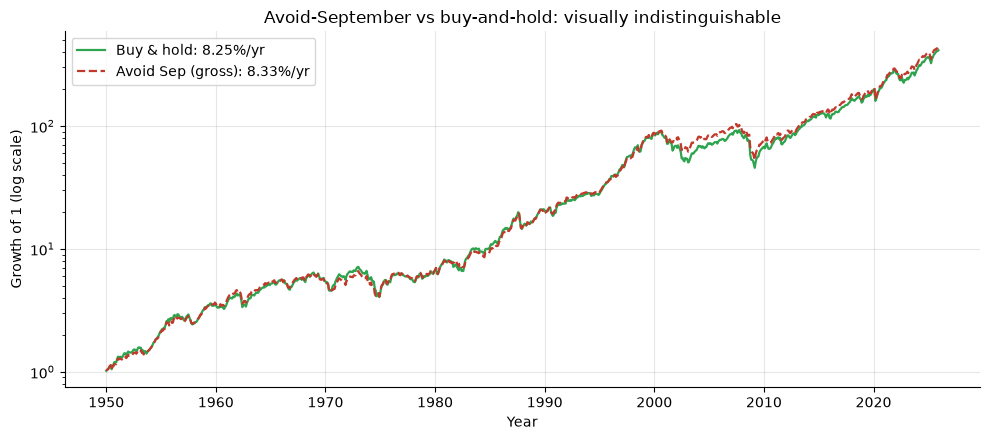

Buy & hold:        8.253%/yr
Avoid Sep (gross): 8.326%/yr  (edge +0.073pp)
Avoid Sep (net):   8.226%/yr  (edge -0.027pp) -- before tax


In [6]:
if HAVE_REAL:
    bt = st.avoid_september_backtest(df, one_way_bps=5.0)
    bh, gross, net = bt['buyhold_ann_pct'], bt['strat_gross_ann_pct'], bt['strat_net_ann_pct']
    work = df.copy()
    years = work['year'].values
    bh_cum = (1+work['ret']).cumprod().values
    flat = np.where(work['month'].values==9, 0.0, work['ret'].values)
    st_cum = (1+flat).cumprod()
    dates = work['date'].values
else:
    bh, gross, net = R['bt_buyhold_ann_pct'], R['bt_strat_gross_ann_pct'], R['bt_strat_net_ann_pct']
    rng2 = np.random.default_rng(290)
    dates = pd.date_range('1950-01-31', periods=R['n_total'], freq='ME')
    r = rng2.normal(R['other_mean_pct']/100, 0.037, R['n_total'])
    bh_cum = (1+r).cumprod()
    flat = np.where(dates.month==9, 0.0, r)
    st_cum = (1+flat).cumprod()

fig, ax = plt.subplots(figsize=(10.0, 4.5))
ax.plot(dates, bh_cum, lw=1.6, c=GREEN, label=f'Buy & hold: {bh:.2f}%/yr')
ax.plot(dates, st_cum, lw=1.6, c=RED, ls='--', label=f'Avoid Sep (gross): {gross:.2f}%/yr')
ax.set_yscale('log'); ax.set_xlabel('Year')
ax.set_ylabel('Growth of 1 (log scale)')
ax.set_title('Avoid-September vs buy-and-hold: visually indistinguishable')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Buy & hold:        {bh:.3f}%/yr')
print(f'Avoid Sep (gross): {gross:.3f}%/yr  (edge {gross-bh:+.3f}pp)')
print(f'Avoid Sep (net):   {net:.3f}%/yr  (edge {net-bh:+.3f}pp) -- before tax')

> The two equity curves lie on top of each other. The gross edge is a rounding error; net of trading it is negative; and on a taxable book selling every August realises gains that compound the drag. There is no trade.

## 7 - Going further -- the synthetic positive control

Does the machinery detect a September drag *when one exists*? We plant a known September premium in a synthetic tape and sweep its size.

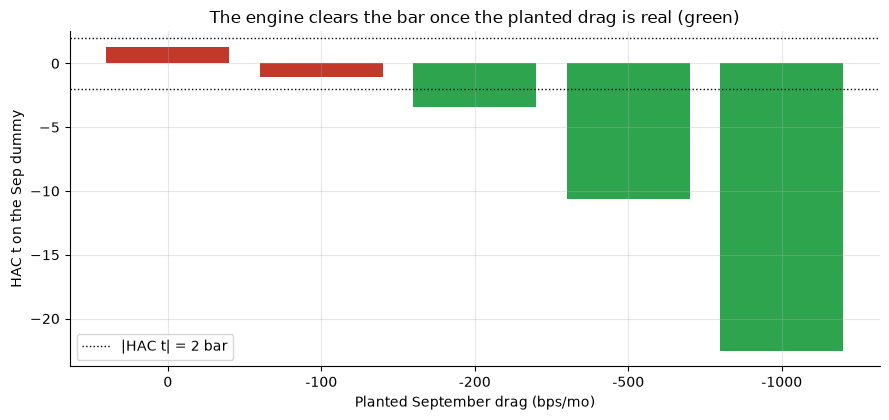

 sep_bps  gap_pct  hac_t_gap  perm_p
       0    0.552      1.317   0.880
    -100   -0.448     -1.070   0.176
    -200   -1.448     -3.458   0.000
    -500   -4.448    -10.622   0.000
   -1000   -9.448    -22.561   0.000


In [7]:
planted = [0, -100, -200, -500, -1000]
rows = []
for bps in planted:
    df_s, _ = data.synthetic_monthly(n_years=76, sep_bps=float(bps), seed=290)
    rr = st.september_stats(df_s, n_permutations=500, seed=99)
    rows.append({'sep_bps': bps, 'gap_pct': rr['gap_pct'],
                 'hac_t_gap': rr['hac_t_gap'], 'perm_p': rr['perm_p']})
ctrl = pd.DataFrame(rows)

colors = [GREEN if abs(r['hac_t_gap']) >= 2 else RED for r in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(r['sep_bps']) for r in rows], [r['hac_t_gap'] for r in rows], color=colors)
ax.axhline(-2, c='k', ls=':', lw=1, label='|HAC t| = 2 bar')
ax.axhline(2, c='k', ls=':', lw=1)
ax.set_xlabel('Planted September drag (bps/mo)')
ax.set_ylabel('HAC t on the Sep dummy')
ax.set_title('The engine clears the bar once the planted drag is real (green)')
ax.legend(); plt.tight_layout(); plt.show()
print(ctrl.to_string(index=False))

The engine recovers a planted September drag cleanly: once the drag is around -200 bps/mo or larger the HAC t blows past the |t| >= 2 bar. The real tape's ~-79 bps/mo gap sits right at the edge of detectability with only 76 Septembers -- the verdict is a statement about the **market and sample size**, not the method.